In [1]:
# Import core libraries for data manipulation, numerical computing, and visualisation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the marketing campaigns CSV into a DataFrame and preview the first 5 rows
camp_df = pd.read_csv('F:\Self Study Projects\Marketing Campaigns\marketing_campaigns.csv')
camp_df.head()

,campaign_id,campaign_name,channel,campaign_type,status,industry,currency,start_date,end_date,release_date,...,device,ad_copies_tested,creative_score,campaign_manager,team_size,landing_page_url,email_contact,data_source,last_updated,notes
0,CMP-012311,Summer Sale 2021,Affiliate,Engagement,Paused,Automotive,USD,2025-08-18,NaN,NaN,...,Mobile,11,3.9,Diana Prince,23,example.com/sale,copyzzeoq@company.com,CRM,2023-05-05,NaN
1,CMP-000537,Win-back 2016,Affiliate,Engagement,Completed,Retail,USD,2025-08-08,2025-07-24,2025-08-05,...,Tablet,18,2.0,James Wright,47,www.company.com/offer,utylenlr@,HubSpot,2020-05-23,NaN
2,CMP-004425,Awareness Blitz 2019,Email,Lead Generation,Completed,Retail,CAD,2025-08-24,NaN,NaN,...,Desktop,10,2.9,Frank Lee,18,NaN,cnsowzuio@company.com,HubSpot,02-26-2017,NaN
3,CMP-007602,New Year Campaign 2016,Organic,Lead Generation,Completed,Retail,EUR,2025-07-11,NaN,NaN,...,Mobile,10,5.3,Hiro Tanaka,15,NaN,tmapwnbsq@company.com,HubSpot,2018-07-17,duplicate?
4,CMP-001334,Product Launch v2,Social Media,Conversion,Active,E-commerce,AUD,2025-11-19,2026-10-07,NaN,...,Desktop,4,3.3,Hiro Tanaka,2,NaN,smgcfop@outlook.com,Manual,2024-11-21,legacy data


In [4]:
# Check the number of rows and columns in the dataset
camp_df.shape

(624, 43)

In [5]:
# List all column names to understand available features
camp_df.columns

Index(['campaign_id', 'campaign_name', 'channel', 'campaign_type', 'status',
       'industry', 'currency', 'start_date', 'end_date', 'release_date',
       'region', 'gender_target', 'customer_segment', 'budget', 'spend',
       'revenue', 'impressions', 'clicks', 'conversions', 'leads', 'ctr',
       'cpc', 'cpa', 'roas', 'roi', 'engagement_rate', 'bounce_rate',
       'avg_session_duration_sec', 'social_shares', 'email_open_rate',
       'email_ctr', 'unsubscribes', 'nps_score', 'device', 'ad_copies_tested',
       'creative_score', 'campaign_manager', 'team_size', 'landing_page_url',
       'email_contact', 'data_source', 'last_updated', 'notes'],
      dtype='object')

In [6]:
# Inspect data types for all columns to identify type mismatches
camp_df.dtypes

campaign_id                  object
campaign_name                object
channel                      object
campaign_type                object
status                       object
industry                     object
currency                     object
start_date                   object
end_date                     object
release_date                 object
region                       object
gender_target                object
customer_segment             object
budget                      float64
spend                       float64
revenue                     float64
impressions                 float64
clicks                      float64
conversions                 float64
leads                       float64
ctr                          object
cpc                          object
cpa                          object
roas                         object
roi                          object
engagement_rate             float64
bounce_rate                 float64
avg_session_duration_sec    

In [7]:
# Narrow down dtypes for a specific column range (bounce_rate → landing_page_url)
camp_df.loc[:, 'engagement_rate':'landing_page_url'].dtypes

engagement_rate             float64
bounce_rate                 float64
avg_session_duration_sec    float64
social_shares               float64
email_open_rate             float64
email_ctr                   float64
unsubscribes                float64
nps_score                   float64
device                       object
ad_copies_tested              int64
creative_score              float64
campaign_manager             object
team_size                     int64
landing_page_url             object
dtype: object

In [8]:
# Preview the derived metric columns (CTR, CPC, CPA, ROAS) to check current values before recalculation
camp_df[['ctr', 'cpc', 'cpa', 'roas']]

,ctr,cpc,cpa,roas
0,"6,4335",1.25,9.00,3.56
1,2.56,"1,8761",13.88,6.06
2,2.77,NaN,0.61,4.53
3,7.80,0.54,5.77,0.56
4,14.94,NaN,3.28,NaN
...,...,...,...,...
619,2.58,"1,9495",8.33,1.48
620,NaN,0.24,1.14,2.67
621,NaN,0.24,2.05,NaN
622,7.50,$1.16,38.58,7.42


(array([173., 131.,  85.,  61.,  49.,  39.,  32.,  12.,  14.,  12.]),
 array([1.0540000e+03, 1.4399980e+05, 2.8694560e+05, 4.2989140e+05,
        5.7283720e+05, 7.1578300e+05, 8.5872880e+05, 1.0016746e+06,
        1.1446204e+06, 1.2875662e+06, 1.4305120e+06]),
 <BarContainer object of 10 artists>)

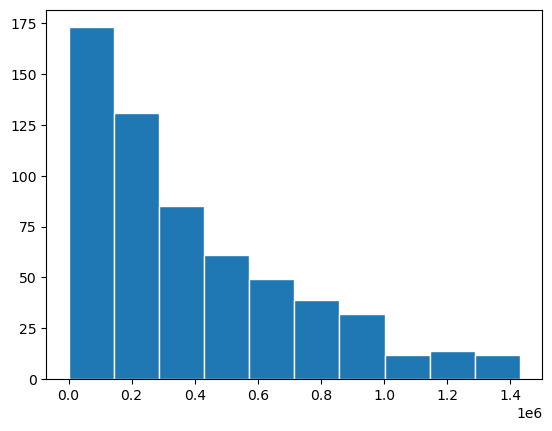

In [9]:
# Visualise the distribution of clicks to spot skewness or extreme values
plt.hist(camp_df['clicks'], edgecolor='white')

(array([56., 59., 55., 66., 59., 74., 59., 55., 60., 65.]),
 array([  30578., 1022523., 2014468., 3006413., 3998358., 4990303.,
        5982248., 6974193., 7966138., 8958083., 9950028.]),
 <BarContainer object of 10 artists>)

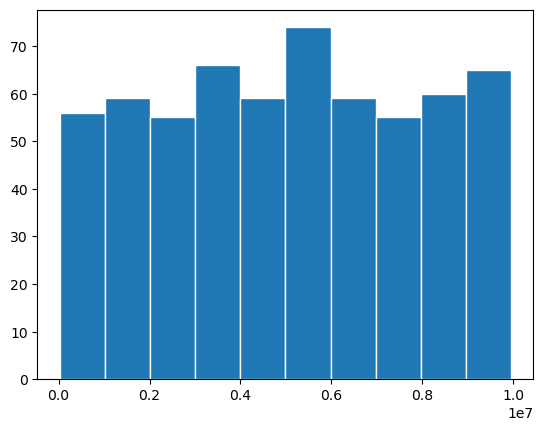

In [10]:
# Visualise the distribution of impressions alongside clicks for comparison
plt.hist(camp_df['impressions'], edgecolor='white')

In [11]:
# Preview raw date strings before type conversion
camp_df[['start_date', 'end_date', 'last_updated']]

,start_date,end_date,last_updated
0,2025-08-18,NaN,2023-05-05
1,2025-08-08,2025-07-24,2020-05-23
2,2025-08-24,NaN,02-26-2017
3,2025-07-11,NaN,2018-07-17
4,2025-11-19,2026-10-07,2024-11-21
...,...,...,...
619,2025-01-10,NaN,03/01/2024
620,2025-12-06,2026-07-12,"July 26, 2020"
621,2025-11-11,NaN,2017-01-16
622,2025-10-09,NaN,13-10-2016


In [12]:
# Convert start_date, end_date, and last_updated from object/string to proper datetime64 type
camp_df['start_date'] = camp_df['start_date'].astype('datetime64[s]')
camp_df['end_date'] = camp_df['end_date'].astype('datetime64[s]')
camp_df['last_updated'] = camp_df['last_updated'].astype('datetime64[s]')

In [13]:
# Verify the date columns now display as datetime objects after conversion
camp_df[['start_date', 'end_date', 'last_updated']]

,start_date,end_date,last_updated
0,2025-08-18,NaT,2023-05-05
1,2025-08-08,2025-07-24,2020-05-23
2,2025-08-24,NaT,2017-02-26
3,2025-07-11,NaT,2018-07-17
4,2025-11-19,2026-10-07,2024-11-21
...,...,...,...
619,2025-01-10,NaT,2024-03-01
620,2025-12-06,2026-07-12,2020-07-26
621,2025-11-11,NaT,2017-01-16
622,2025-10-09,NaT,2016-10-13


In [14]:
# Define exchange rates relative to USD for all currencies present in the dataset
change_rate = {
    'USD': 1,
    'EUR': 1.16,
    'GBP': 1.34,
    'AUD': 0.72,
    'CAD': 0.73
}

In [15]:
# Map each row's currency code to its USD conversion rate
camp_df['rate_to_usd'] = camp_df['currency'].map(change_rate)
camp_df[['currency','rate_to_usd']]

,currency,rate_to_usd
0,USD,1.00
1,USD,1.00
2,CAD,0.73
3,EUR,1.16
4,AUD,0.72
...,...,...
619,USD,1.00
620,USD,1.00
621,EUR,1.16
622,USD,1.00


In [16]:
# Compute USD-equivalent columns for budget, spend, and revenue using the mapped rates
money_cols = ['budget', 'spend', 'revenue']
for col in money_cols:
    camp_df[f'{col}_usd'] = round(camp_df[col] * camp_df['rate_to_usd'], 2)

In [17]:
# Validate the newly created USD-converted monetary columns side-by-side with originals
camp_df[['currency', 'budget', 'budget_usd', 'spend','spend_usd', 'revenue', 'revenue_usd']]

,currency,budget,budget_usd,spend,spend_usd,revenue,revenue_usd
0,USD,342901.87,342901.87,182724.67,182724.67,559907.72,559907.72
1,USD,382642.30,382642.30,384482.97,384482.97,2263668.22,2263668.22
2,CAD,14392.53,10506.55,8185.96,5975.75,40320.52,29433.98
3,EUR,269073.11,312124.81,248470.04,288225.25,1037123.96,1203063.79
4,AUD,347052.54,249877.83,318334.65,229200.95,715682.65,515291.51
...,...,...,...,...,...,...,...
619,USD,280016.24,280016.24,309850.52,309850.52,1507172.06,1507172.06
620,USD,61564.81,61564.81,46348.07,46348.07,110704.91,110704.91
621,EUR,270407.82,313673.07,150663.12,174769.22,368556.29,427525.30
622,USD,487936.22,487936.22,461683.13,461683.13,1489267.74,1489267.74


In [18]:
# Inspect raw values in gender_target to identify inconsistent casing and abbreviations
camp_df['gender_target'].value_counts()

gender_target
Male      306
Female    173
male       35
female     25
F          20
MALE       16
M          13
FEMALE     11
Name: count, dtype: int64

In [20]:
# Standardise gender_target: unify all variants (F, female, FEMALE → Female; M, male, MALE → Male)
camp_df['gender_target'].replace({'female':'Female','F':'Female','MALE':'Male','FEMALE':'Female','M':'Male','male':'Male'}, inplace=True)

In [21]:
# Confirm gender_target now contains only clean, consistent values
camp_df['gender_target'].value_counts()

gender_target
Male      370
Female    229
Name: count, dtype: int64

In [22]:
# Inspect data_source for inconsistent casing before standardisation
camp_df['data_source'].value_counts()

data_source
Salesforce    191
HubSpot       154
CRM            80
API            46
Manual         34
Export         25
hubspot        20
crm            17
manual         14
api            11
Unknown        10
Name: count, dtype: int64

In [24]:
# Standardise data_source labels (e.g. 'api' → 'API', 'hubspot' → 'HubSpot')
camp_df['data_source'].replace({'api':'API','hubspot':'HubSpot','manual':'Manual','crm':'CRM'}, inplace=True)

<Axes: xlabel='data_source', ylabel='Count'>

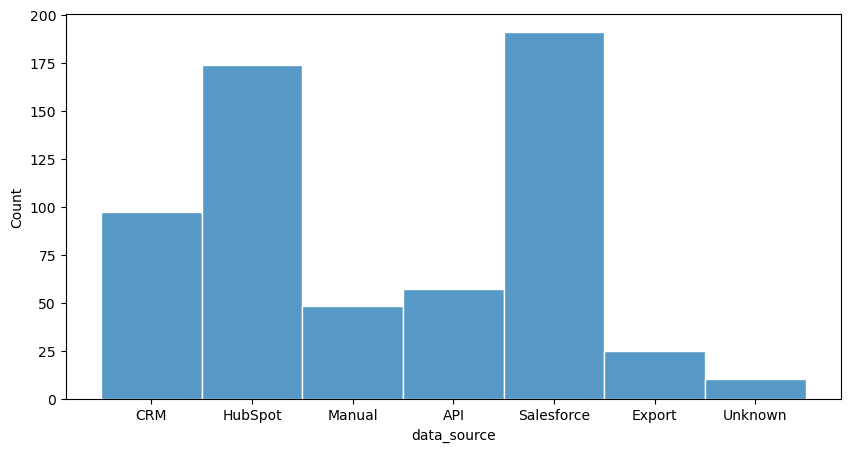

In [25]:
# Confirm standardised values and plot distribution of data sources
camp_df['data_source'].value_counts()
plt.figure(figsize=(10,5))
sns.histplot(camp_df['data_source'], edgecolor='white')

In [26]:
# Inspect region values to detect inconsistent naming conventions
camp_df['region'].value_counts()

region
North America    185
Europe           128
Asia Pacific      76
Latin America     39
north america     25
Africa            23
Middle East       18
LATAM             17
Asia-Pacific      17
APAC              17
europe            15
EU                13
ME                 6
latam              2
Other              2
Name: count, dtype: int64

In [28]:
# Standardise region labels: unify abbreviations and mixed-case variants
# e.g. 'north_america' / 'north america' → 'North America', 'APAC' → 'Asia Pacific', 'LATAM' → 'Latin America'
camp_df['region'].replace(
                        {
                            'north_america':'North America',
                            'north america':'North America',
                            'Asia-Pacific':'Asia Pacific',
                            'APAC':'Asia Pacific',
                            'europe':'Europe',
                            'asia':'Asia',
                            'south_america':'South America',
                            'africa':'Africa',
                            'LATAM':'Latin America',
                            'latam':'Latin America',
                            'EU':'Europe',
                            'ME':'Middle East'
                        },
                        inplace=True)
camp_df['region'].value_counts()

region
North America    210
Europe           156
Asia Pacific     110
Latin America     58
Middle East       24
Africa            23
Other              2
Name: count, dtype: int64

In [29]:
# Check for missing values in rows where campaign status is Completed or Inactive
# These rows should be fully populated, so nulls here may indicate data quality issues
camp_df[(camp_df['status'] == 'Completed') | (camp_df['status'] == 'Inactive')].isna().sum()

campaign_id                   0
campaign_name                 0
channel                       0
campaign_type                 0
status                        0
industry                      0
currency                      0
start_date                    0
end_date                    153
release_date                156
region                       21
gender_target                11
customer_segment             15
budget                        0
spend                         6
revenue                       6
impressions                   8
clicks                        8
conversions                   8
leads                         8
ctr                          28
cpc                          31
cpa                          27
roas                         30
roi                          31
engagement_rate               8
bounce_rate                   0
avg_session_duration_sec     10
social_shares                 6
email_open_rate              11
email_ctr                    16
unsubscr

In [30]:
# Inspect raw customer_segment values to identify inconsistent naming
camp_df['customer_segment'].value_counts()

customer_segment
High Value    146
Loyal         142
New            88
At-Risk        46
Churned        44
General        32
VIP            26
high_value     24
loyal          18
churned        10
at_risk         8
new             5
Name: count, dtype: int64

In [32]:
# Standardise customer_segment labels
# e.g. 'high_value' → 'High Value', 'at_risk' / 'At-Risk' → 'At Risk'
camp_df['customer_segment'].replace(
                                    {
                                        'high_value':'High Value',
                                        'loyal':'Loyal',
                                        'new':'New',
                                        'churned':'Churned',
                                        'at_risk':'At Risk',
                                        'At-Risk':'At Risk',
                                    }, 
                                    inplace=True)
camp_df['customer_segment'].value_counts()

customer_segment
High Value    170
Loyal         160
New            93
Churned        54
At Risk        54
General        32
VIP            26
Name: count, dtype: int64

In [33]:
# Count rows where start_date is incorrectly later than end_date (inverted date pairs)
camp_df[camp_df['start_date'] > camp_df['end_date']].shape[0]

13

In [34]:
# Create corrected end_date: swap where start > end so the later date always becomes end_date
camp_df['new_end_date'] = np.where(camp_df['start_date'] > camp_df['end_date'], camp_df['start_date'], camp_df['end_date'])

In [35]:
# Create corrected start_date: the earlier of the two original dates
camp_df['new_start_date'] = np.where(camp_df['start_date'] > camp_df['end_date'], camp_df['end_date'], camp_df['start_date'])

In [36]:
# Drop the original (potentially swapped) date columns and rename corrected ones
# Also compute campaign duration in days as a new feature
camp_df.drop(columns=['start_date', 'end_date'], axis= 1 ,inplace=True)
camp_df.rename(columns={'new_start_date': 'start_date', 'new_end_date': 'end_date'}, inplace=True)
camp_df['duration in days'] = (camp_df['end_date'] - camp_df['start_date']).dt.days

In [37]:
# Verify the corrected date columns and the newly derived duration column
camp_df[['start_date', 'end_date', 'duration in days']]

,start_date,end_date,duration in days
0,2025-08-18,NaT,NaN
1,2025-07-24,2025-08-08,15.0
2,2025-08-24,NaT,NaN
3,2025-07-11,NaT,NaN
4,2025-11-19,2026-10-07,322.0
...,...,...,...
619,2025-01-10,NaT,NaN
620,2025-12-06,2026-07-12,218.0
621,2025-11-11,NaT,NaN
622,2025-10-09,NaT,NaN


In [38]:
# List all available columns to select numeric candidates for outlier checking
camp_df.columns

Index(['campaign_id', 'campaign_name', 'channel', 'campaign_type', 'status',
       'industry', 'currency', 'release_date', 'region', 'gender_target',
       'customer_segment', 'budget', 'spend', 'revenue', 'impressions',
       'clicks', 'conversions', 'leads', 'ctr', 'cpc', 'cpa', 'roas', 'roi',
       'engagement_rate', 'bounce_rate', 'avg_session_duration_sec',
       'social_shares', 'email_open_rate', 'email_ctr', 'unsubscribes',
       'nps_score', 'device', 'ad_copies_tested', 'creative_score',
       'campaign_manager', 'team_size', 'landing_page_url', 'email_contact',
       'data_source', 'last_updated', 'notes', 'rate_to_usd', 'budget_usd',
       'spend_usd', 'revenue_usd', 'end_date', 'start_date',
       'duration in days'],
      dtype='object')

In [39]:
# Apply IQR-based outlier detection across all selected numeric columns
# Prints the count of outlier rows per column (beyond 1.5 × IQR from Q1/Q3)
check_outliers_cols = ['budget', 'spend', 'revenue', 'engagement_rate',
       'bounce_rate', 'avg_session_duration_sec', 'social_shares',
       'email_open_rate', 'email_ctr', 'unsubscribes', 'nps_score']
for col in check_outliers_cols:
    q1 = camp_df[col].quantile(0.25)
    q3 = camp_df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = camp_df[(camp_df[col] < lower_bound) | (camp_df[col] > upper_bound)]
    print(f'{col}: {outliers.shape[0]}')

budget: 0
spend: 0
revenue: 19
engagement_rate: 0
bounce_rate: 7
avg_session_duration_sec: 0
social_shares: 0
email_open_rate: 0
email_ctr: 0
unsubscribes: 0
nps_score: 0


<Axes: xlabel='revenue', ylabel='Count'>

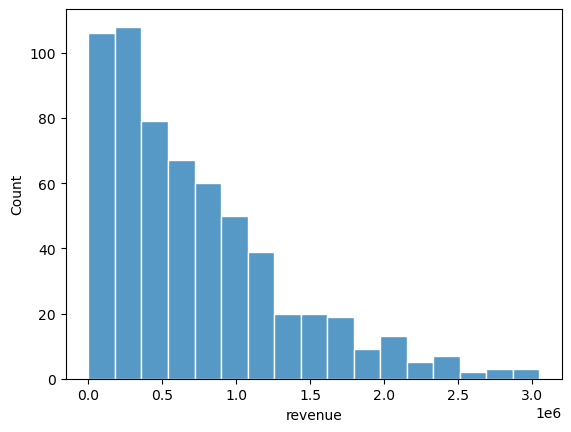

In [40]:
# Visualise revenue distribution before outlier treatment to understand its shape
sns.histplot(camp_df['revenue'], edgecolor='white')

In [41]:
# Calculate IQR bounds and median for revenue — used to cap outliers at the median
revenue_q1 = camp_df['revenue'].quantile(0.25)
revenue_q3 = camp_df['revenue'].quantile(0.75)
revenue_iqr = revenue_q3 - revenue_q1
revenue_lower_bound = revenue_q1 - 1.5 * revenue_iqr
revenue_upper_bound = revenue_q3 + 1.5 * revenue_iqr
revenue_median = camp_df['revenue'].median()

In [42]:
# Replace revenue outliers (beyond IQR bounds) with the median value
# Using median avoids introducing further skew caused by extreme values
outliers = (camp_df['revenue'] > revenue_upper_bound) | (camp_df['revenue'] < revenue_lower_bound)
camp_df.loc[outliers, 'revenue'] = revenue_median

<Axes: xlabel='bounce_rate', ylabel='Count'>

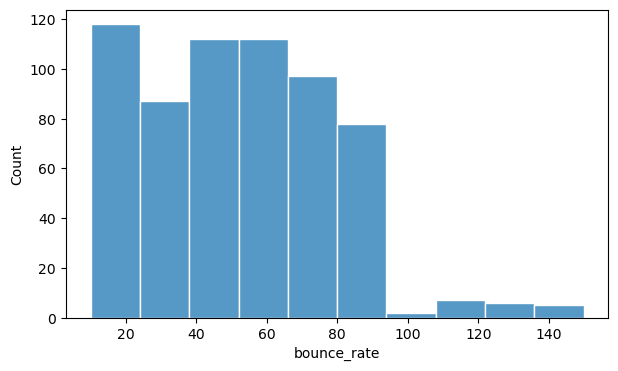

In [43]:
# Visualise bounce_rate distribution before treatment — values > 100% are physically impossible
plt.figure(figsize=(7,4))
sns.histplot(camp_df['bounce_rate'], edgecolor='white', bins=10)

In [44]:
# Calculate the mean bounce rate using only valid rows (bounce_rate < 100)
# This mean will replace impossible out-of-range values
bounce_rate_mean = camp_df[camp_df['bounce_rate'] < 100]['bounce_rate'].mean()
bounce_rate_mean

np.float64(49.411059602649004)

In [45]:
# Replace all bounce_rate values greater than 100 with the valid mean
camp_df.loc[camp_df['bounce_rate'] > 100, 'bounce_rate'] = bounce_rate_mean

<Axes: xlabel='bounce_rate', ylabel='Count'>

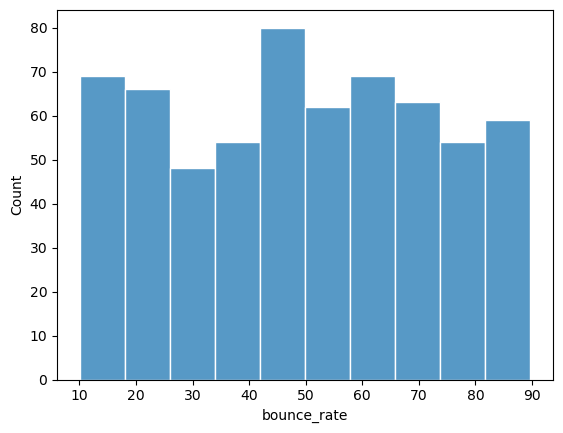

In [46]:
# Visualise bounce_rate distribution after treatment to confirm outliers are resolved
sns.histplot(camp_df['bounce_rate'], edgecolor='white', bins=10)

In [47]:
# Recalculate performance metrics using cleaned spend, clicks, conversions, and revenue:
# CTR  = clicks / impressions × 100
# CPC  = spend / clicks × 100
# CPA  = spend / conversions × 100
# ROAS = revenue / spend × 100
# ROI  = (revenue - spend) / spend × 100
# engagement_rate is derived as the complement of bounce_rate
d = {
    'ctr' : ['clicks', 'impressions'],
    'cpc' : ['spend', 'clicks'],
    'cpa' : ['spend', 'conversions'],
    'roas' : ['revenue', 'spend'],
    }

for i,k in d.items():
    camp_df[i] = round(camp_df[k[0]] / camp_df[k[1]] * 100, 2)

camp_df['roi'] = round((camp_df['revenue'] - camp_df['spend']) / camp_df['spend'] * 100, 2)
camp_df['engagement_rate'] = 100 - camp_df['bounce_rate']

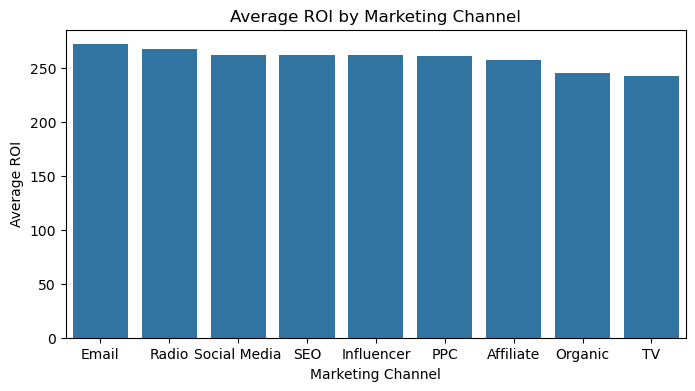

In [48]:
# Bar chart: compare average ROI across marketing channels
# Sorted descending to highlight the best-performing channel
# which marketing channel has the highest average roi?

roi_by_channel = round(camp_df.groupby('channel')['roi'].mean().sort_values(ascending=False), 2)

plt.figure(figsize=(8,4))
sns.barplot(x=roi_by_channel.index, y=roi_by_channel.values)
plt.title('Average ROI by Marketing Channel')
plt.xlabel('Marketing Channel')
plt.ylabel('Average ROI')
plt.show()

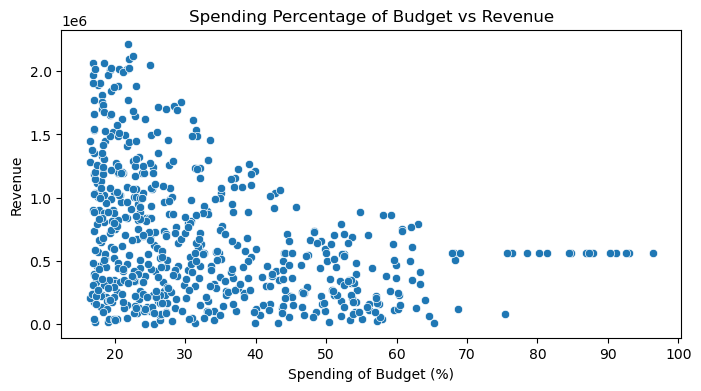

Correlation Coefficient: -0.33


In [49]:
# Scatter plot: explore whether spend as a % of budget correlates with higher revenue
# Pearson correlation coefficient printed below the chart
# Relationship between spending percentage of budget and revenue

camp_df['spend_%_of_budget'] = round(camp_df['spend'] / camp_df['revenue'] * 100, 2)

plt.figure(figsize=(8,4))
sns.scatterplot(x=camp_df['spend_%_of_budget'], y=camp_df['revenue'])
plt.title('Spending Percentage of Budget vs Revenue')
plt.xlabel('Spending of Budget (%)')
plt.ylabel('Revenue')
plt.show()
print('Correlation Coefficient:',round(camp_df['spend_%_of_budget'].corr(camp_df['revenue']), 2))

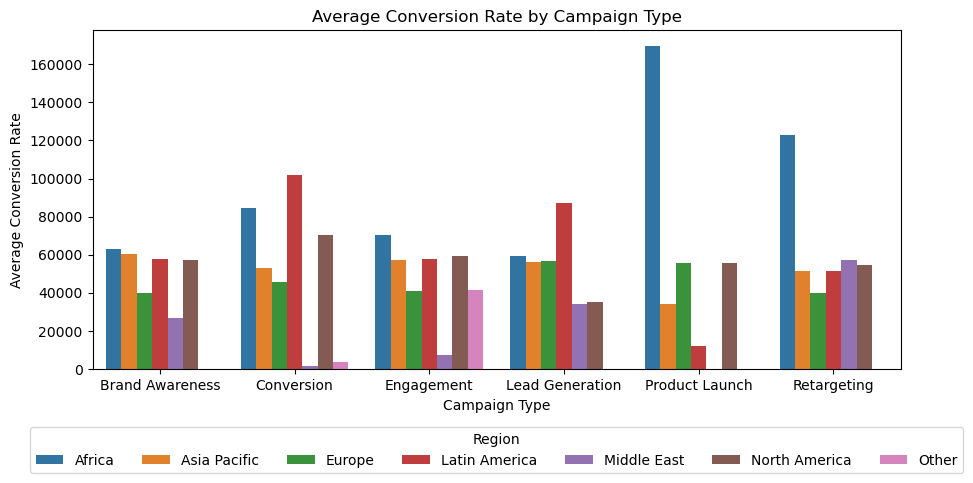

In [52]:
# Grouped bar chart: average conversions broken down by campaign type and region
# Shows which campaign type × region combinations drive the most conversions
# which campaign type has the highest average conversions?

conversion_rate_by_type_region = round(camp_df.groupby(['campaign_type', 'region'])['conversions'].mean().reset_index(), 2)

plt.figure(figsize=(10,5))
sns.barplot(data=conversion_rate_by_type_region, x='campaign_type', y='conversions', hue='region')
plt.title('Average Conversion Rate by Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Average Conversion Rate')
plt.legend(title='Region', bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=7)
plt.tight_layout()
plt.show()

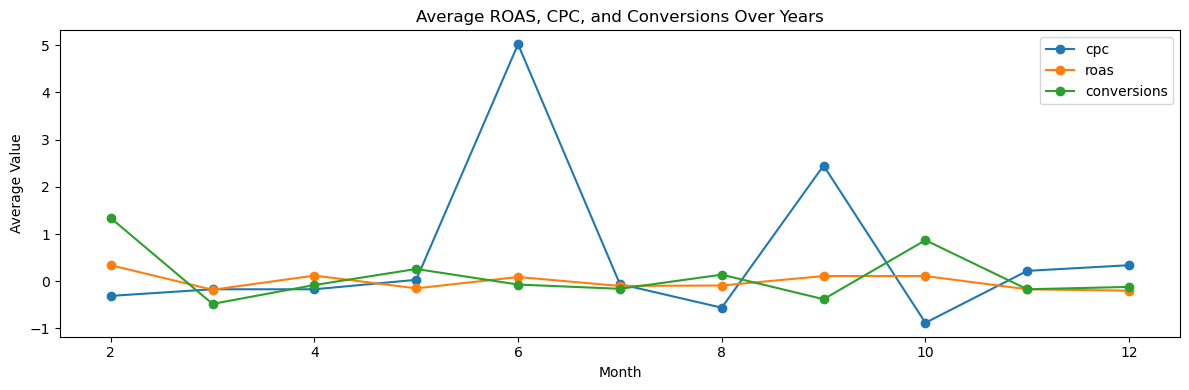

In [54]:
# Line chart: month-over-month trends for ROAS, CPC, and conversions
# % change (pct_change) highlights acceleration or decline across months
# ROAS, CPC, and Conversions Over Years

camp_df['end_month'] = camp_df['end_date'].dt.month
roas_cpc_convs_over_years = camp_df.groupby('end_month')[['cpc', 'roas', 'conversions']].mean().reset_index().round(2)
YOY = roas_cpc_convs_over_years.set_index('end_month').pct_change().round(2)
YOY.plot(
    kind='line', 
    marker='o', 
    figsize=(12,4), 
    title='Average ROAS, CPC, and Conversions Over Years'
)
plt.xlabel('Month')
plt.ylabel('Average Value')
plt.tight_layout()
plt.show()

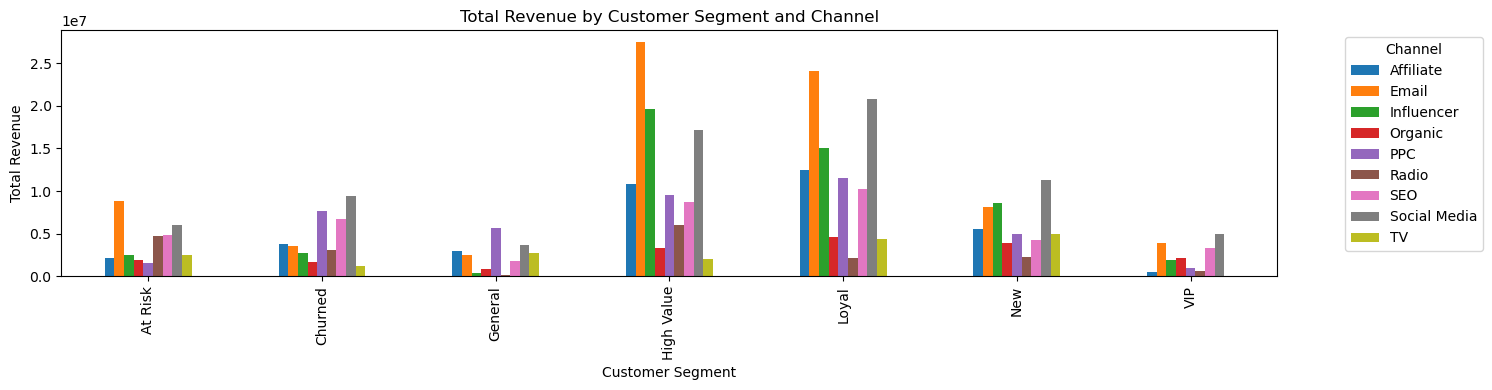

In [55]:
# Stacked bar chart via pivot table: total revenue broken down by customer segment and channel
# Reveals which segments and channels contribute most to overall revenue
segment_channel_revenue = pd.pivot_table(camp_df, values='revenue', index='customer_segment', columns='channel', aggfunc='sum').round(2)
segment_channel_revenue.plot(
    kind='bar',
    figsize=(15,4),
    title='Total Revenue by Customer Segment and Channel'
)
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')
plt.legend(title='Channel', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

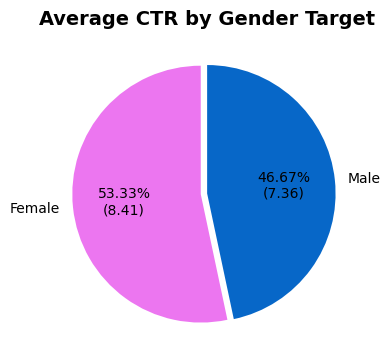

In [56]:
# Pie chart: compare average CTR between gender targets (Female vs Male)
# Exploded slice highlights the leading gender segment
ctr_by_gender = camp_df.groupby('gender_target')['ctr'].mean().sort_values(ascending=False).round(2)

plt.figure(figsize=(4, 4))
plt.pie(ctr_by_gender.values, 
        labels=ctr_by_gender.index, 
        autopct=lambda x: f'{x:.2f}%\n({x * sum(ctr_by_gender.values) / 100:.2f})',
        startangle=90,
        explode=[0.05, 0],
        colors=[ "#ec76f0", "#0767c8"])
plt.title('Average CTR by Gender Target', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

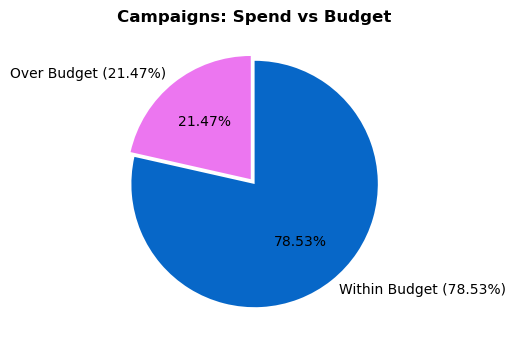

In [ ]:
# Pie chart: proportion of campaigns that exceeded their allocated budget vs stayed within it

spend_over_budget_percentage = round(camp_df[camp_df['spend'] > camp_df['budget']].shape[0] / camp_df.shape[0] * 100, 2)
within_budget_percentage = 100 - spend_over_budget_percentage

plt.figure(figsize=(4, 4))
plt.pie([spend_over_budget_percentage, within_budget_percentage], 
        labels=[f'Over Budget ({spend_over_budget_percentage}%)', f'Within Budget ({within_budget_percentage}%)'],
        colors=['#ec76f0', '#0767c8'],
        autopct='%1.2f%%',
        startangle=90,
        explode=(0.05, 0))
plt.title('Campaigns: Spend vs Budget', fontsize=12, fontweight='bold')
plt.show()

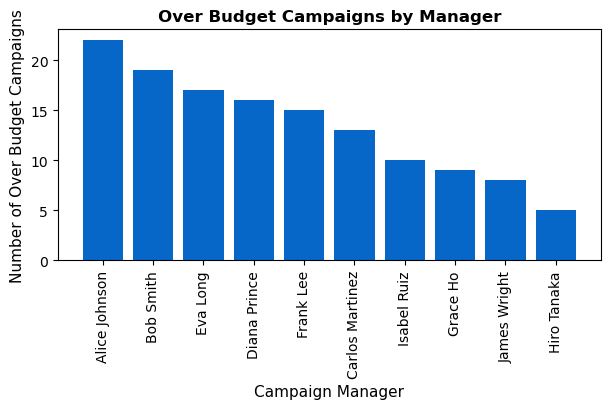

In [58]:
# Bar chart: count of over-budget campaigns per campaign manager
# Identifies managers most frequently associated with budget overruns

spend_over_budget_df = camp_df[camp_df['spend'] > camp_df['budget']]['campaign_manager'].value_counts()

plt.figure(figsize=(7,3))
plt.bar(spend_over_budget_df.index, spend_over_budget_df.values, color='#0767c8')
plt.xlabel('Campaign Manager', fontsize=11)
plt.ylabel('Number of Over Budget Campaigns', fontsize=11)
plt.title('Over Budget Campaigns by Manager', fontsize=12, fontweight='bold')
plt.tick_params(axis='x', rotation=90)
plt.show()

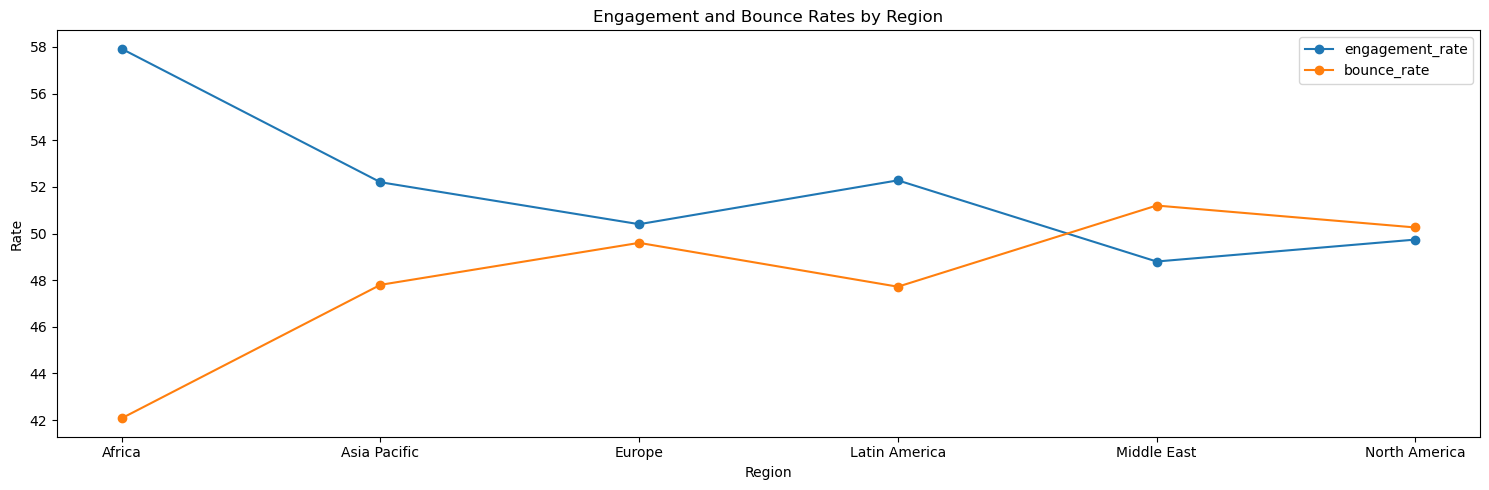

In [51]:
# Line chart: average engagement rate and bounce rate by geographic region
# Excludes 'Other' category for a cleaner regional comparison
engagement_bounce_rate_by_region = camp_df[camp_df['region'] != 'Other'].groupby('region')[['engagement_rate', 'bounce_rate']].mean().round(2)

engagement_bounce_rate_by_region.plot(kind='line', marker='o', figsize=(15,5))
plt.xlabel('Region')
plt.ylabel('Rate')
plt.title('Engagement and Bounce Rates by Region')
plt.tight_layout()
plt.show()


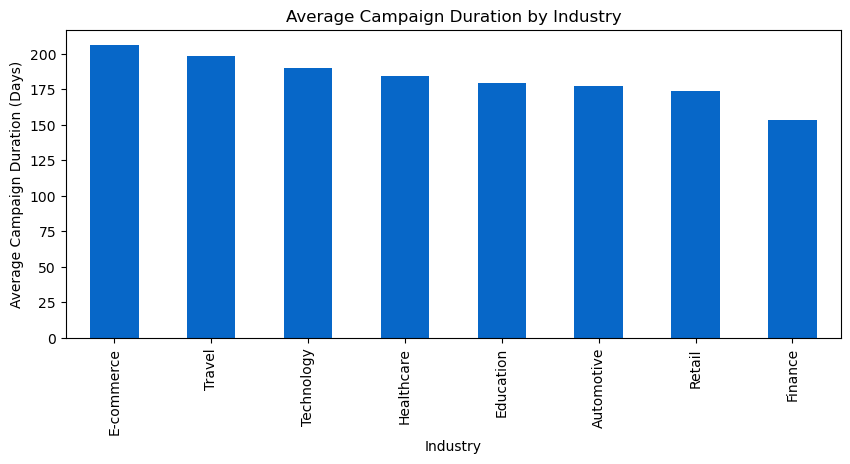

In [ ]:
# Bar chart: average campaign duration (days) grouped by industry
# Helps understand how long different industries typically run their campaigns

camp_df['campaign_duration'] = (camp_df['end_date'] - camp_df['start_date']).dt.days

avg_duration_by_industry = camp_df.groupby('industry')['campaign_duration'].mean().sort_values(ascending=False).round(2)

avg_duration_by_industry.plot(kind='bar', figsize=(10,4), color='#0767c8')
plt.xlabel('Industry')
plt.ylabel('Average Campaign Duration (Days)')
plt.title('Average Campaign Duration by Industry')
plt.show()